# HODA: Baseline MLP and SVD Rank Study
Outputs below are preserved historical results, not a rerun of this portable copy. See ../docs/REPRODUCIBILITY.md.

In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "HodaDatasetReader.py").exists())
sys.path.insert(0, str(ROOT / "src"))
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


#Libraries

In [26]:
# Install dependencies once using requirements.txt.
import numpy as np
import torch
import time
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import display


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

 Using device: cuda


# Data Loading and Preprocessing

In [2]:
# Local paths are configured in the setup cell.


Mounted at /content/drive


In [3]:
# HODA reader is imported from src/.


Data Loading and Preprocessing

In [4]:
from HodaDatasetReader import read_hoda_dataset

train_path = str(ROOT / "data/raw/hoda/Train 60000.cdb")
test_path = str(ROOT / "data/raw/hoda/Test 20000.cdb")

# Load training and test datasets
X_train, Y_train = read_hoda_dataset(train_path, images_height=32, images_width=32, one_hot=False, reshape=True)
X_test, Y_test = read_hoda_dataset(test_path, images_height=32, images_width=32, one_hot=False, reshape=True)

# Convert datasets to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)


print(f" Minimum pixel value in X_train_tensor: {X_train_tensor.min()}")
print(f" Maximum pixel value in X_train_tensor: {X_train_tensor.max()}")


print(f" X_train shape: {X_train_tensor.shape}, Y_train shape: {Y_train_tensor.shape}")
print(f" X_test shape: {X_test_tensor.shape}, Y_test shape: {Y_test_tensor.shape}")

 Minimum pixel value in X_train_tensor: 0.0
 Maximum pixel value in X_train_tensor: 1.0
 X_train shape: torch.Size([60000, 1024]), Y_train shape: torch.Size([60000])
 X_test shape: torch.Size([20000, 1024]), Y_test shape: torch.Size([20000])


In [5]:
# Check distribution of labels
from collections import Counter
label_counts = Counter(Y_test_tensor.tolist())
print(f" Label distribution in Y_test_tensor: {label_counts}")

 Label distribution in Y_test_tensor: Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000})


**DataLoader Setup**

In [6]:
# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

batch_size = 32

# Create DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True )
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False )

print(f" Number of batches in train_loader: {len(train_loader)}")
print(f" Number of batches in test_loader: {len(test_loader)}")


 Number of batches in train_loader: 1875
 Number of batches in test_loader: 625


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


**Implementing the MLP Model**

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1024, 200)
        self.fc2 = nn.Linear(200, 150)
        self.fc3 = nn.Linear(150, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x

model = Model().to(device)
print(summary(model, input_size=(1, 1024)))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1, 10]                   --
├─Flatten: 1-1                           [1, 1024]                 --
├─Linear: 1-2                            [1, 200]                  205,000
├─ReLU: 1-3                              [1, 200]                  --
├─Linear: 1-4                            [1, 150]                  30,150
├─ReLU: 1-5                              [1, 150]                  --
├─Linear: 1-6                            [1, 10]                   1,510
Total params: 236,660
Trainable params: 236,660
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.95
Estimated Total Size (MB): 0.95


# Training model

In [13]:
def train_model(model, train_loader, num_epochs=30, lr=0.001, patience=5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=patience)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        scheduler.step(epoch_train_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    print(" Training Completed")
    return model


In [14]:
trained_model = train_model(model, train_loader, num_epochs=30, lr=0.001, patience=5)

Epoch [1/30] - Train Loss: 0.1313, Train Accuracy: 96.27%
Epoch [2/30] - Train Loss: 0.0476, Train Accuracy: 98.59%
Epoch [3/30] - Train Loss: 0.0298, Train Accuracy: 99.03%
Epoch [4/30] - Train Loss: 0.0218, Train Accuracy: 99.27%
Epoch [5/30] - Train Loss: 0.0167, Train Accuracy: 99.47%
Epoch [6/30] - Train Loss: 0.0139, Train Accuracy: 99.53%
Epoch [7/30] - Train Loss: 0.0099, Train Accuracy: 99.69%
Epoch [8/30] - Train Loss: 0.0100, Train Accuracy: 99.70%
Epoch [9/30] - Train Loss: 0.0085, Train Accuracy: 99.75%
Epoch [10/30] - Train Loss: 0.0087, Train Accuracy: 99.73%
Epoch [11/30] - Train Loss: 0.0077, Train Accuracy: 99.78%
Epoch [12/30] - Train Loss: 0.0068, Train Accuracy: 99.80%
Epoch [13/30] - Train Loss: 0.0068, Train Accuracy: 99.78%
Epoch [14/30] - Train Loss: 0.0041, Train Accuracy: 99.90%
Epoch [15/30] - Train Loss: 0.0082, Train Accuracy: 99.80%
Epoch [16/30] - Train Loss: 0.0055, Train Accuracy: 99.82%
Epoch [17/30] - Train Loss: 0.0049, Train Accuracy: 99.87%
Epoch 

# Evaluate model

In [10]:
def evaluate_model(model, test_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f" Model Accuracy on Test Data: {accuracy:.2f}%")

    return accuracy

In [15]:
test_accuracy = evaluate_model(model, test_loader)

 Model Accuracy on Test Data: 98.28%


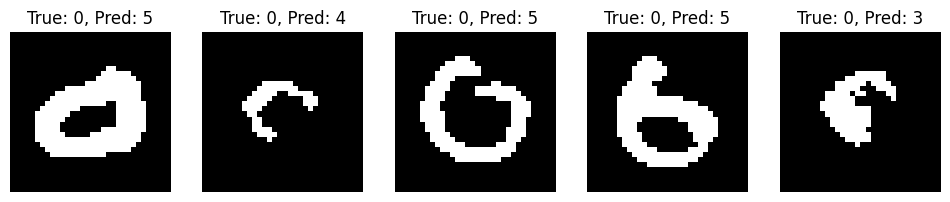

In [16]:
def show_misclassified_images(model, test_loader, num_images=50):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            # Find misclassified samples
            misclassified_indices = (predictions != labels).nonzero(as_tuple=True)[0]

            for idx in misclassified_indices:
                misclassified.append((images[idx].cpu(), labels[idx].cpu().item(), predictions[idx].cpu().item()))

            if len(misclassified) >= num_images:
                break

    # Plot misclassified images
    if len(misclassified) == 0:
        print(" No misclassified images found")
        return

    fig, axes = plt.subplots(1, min(num_images, len(misclassified)), figsize=(12, 4))
    if len(misclassified) == 1:
        axes = [axes]  # Make sure axes is iterable for a single image

    for i, (image, true_label, predicted_label) in enumerate(misclassified[:num_images]):
        axes[i].imshow(image.numpy().reshape(32, 32), cmap="gray")
        axes[i].set_title(f"True: {true_label}, Pred: {predicted_label}", fontsize=12)
        axes[i].axis("off")

    plt.show()

show_misclassified_images(model, test_loader, num_images=5)

# Save Model

In [17]:
model_path = str(OUTPUT_DIR / "mlp_model.pth")

torch.save(model, model_path)

print("Model saved successfully")

Model saved successfully


In [18]:
torch.save(model.state_dict(), str(OUTPUT_DIR / "mlp_weights.pth"))
print(" Model weights saved ")


 Model weights saved 


In [19]:
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"🔹 Layer: {name} | Shape: {param.shape}")


🔹 Layer: fc1.weight | Shape: torch.Size([200, 1024])
🔹 Layer: fc2.weight | Shape: torch.Size([150, 200])
🔹 Layer: fc3.weight | Shape: torch.Size([10, 150])


# **Part B**

# Model with SVD

In [20]:
class SVD_MLP(nn.Module):
    def __init__(self, k=50):
        super(SVD_MLP, self).__init__()
        self.flatten = nn.Flatten()

        # Define original weight matrices
        W1 = torch.randn(1024, 200) * 0.01
        W2 = torch.randn(200, 150) * 0.01
        W3 = torch.randn(150, 10) * 0.01

        # Perform SVD on the original weight matrices
        U1, S1, V1 = torch.svd(W1)
        U2, S2, V2 = torch.svd(W2)
        U3, S3, V3 = torch.svd(W3)

        # Truncate SVD to obtain k-rank approximation
        self.W1_1 = nn.Parameter(U1[:, :k])
        self.W1_2 = nn.Parameter(torch.diag(S1[:k]) @ V1[:, :k].t())

        self.W2_1 = nn.Parameter(U2[:, :k])
        self.W2_2 = nn.Parameter(torch.diag(S2[:k]) @ V2[:, :k].t())

        self.W3_1 = nn.Parameter(U3[:, :k])
        self.W3_2 = nn.Parameter(torch.diag(S3[:k]) @ V3[:, :k].t())

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.flatten(x)

        x = self.relu(x @ self.W1_1 @ self.W1_2)
        x = self.relu(x @ self.W2_1 @ self.W2_2)
        x = self.softmax(x @ self.W3_1 @ self.W3_2)

        return x


# Training model with SVD

In [ ]:
def count_trainable_params(model):

    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def test_different_k(k_values, train_loader, test_loader, num_epochs=30):

    results = []

    accuracies = []
    times = []
    memory_usages = []
    trainable_params_list = []

    for k in k_values:
        print(f"\n Testing model with k={k} ")
        start_time = time.time()

        model = SVD_MLP(k=k).to(device)

        torch.cuda.empty_cache()

        # Store memory usage before training
        if torch.cuda.is_available():
            torch.cuda.reset_max_memory_allocated(device)
        memory_before = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0

        # Count trainable parameters
        trainable_params = count_trainable_params(model)
        trainable_params_list.append(trainable_params)

        # Train the model
        trained_model = train_model(model, train_loader, num_epochs=num_epochs)

        # Evaluate the model
        accuracy = evaluate_model(trained_model, test_loader)
        accuracies.append(accuracy)

        # Store memory usage after training
        memory_after = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0
        memory_used = (memory_after) / (1024 ** 2)  
        memory_usages.append(memory_used)

        # Record execution time
        end_time = time.time()
        elapsed_time = end_time - start_time
        times.append(elapsed_time)

        print(f" k={k} | Accuracy: {accuracy:.2f}% | Memory Usage: {memory_used:.2f} MB | Time: {elapsed_time:.2f} sec | Trainable Params: {trainable_params}")

        results.append([k, accuracy, memory_used, elapsed_time, trainable_params])

    results_df = pd.DataFrame(results, columns=["k", "Test Accuracy (%)", "Memory Usage (MB)", "Time (sec)", "Trainable Params"])

    # Display the results table
    display(results_df)

    # Plot Accuracy vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', label="Test Accuracy")
    plt.xlabel("k value")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Test Accuracy vs k")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot Memory Usage vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, memory_usages, marker='s', linestyle='--', color='r', label="Memory Usage")
    plt.xlabel("k value")
    plt.ylabel("Memory Usage (MB)")
    plt.title("Memory Usage vs k")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot Computation Time vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, times, marker='d', linestyle='-.', color='g', label="Computation Time")
    plt.xlabel("k value")
    plt.ylabel("Time (seconds)")
    plt.title("Computation Time vs k")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot Trainable Parameters vs k
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, trainable_params_list, marker='x', linestyle='-', color='purple', label="Trainable Parameters")
    plt.xlabel("k value")
    plt.ylabel("Number of Trainable Parameters")
    plt.title("Trainable Parameters vs k")
    plt.legend()
    plt.grid()
    plt.show()

    print("Completed")



 Testing model with k=1 
Epoch [1/30] - Train Loss: 2.1523, Train Accuracy: 19.47%
Epoch [2/30] - Train Loss: 2.1396, Train Accuracy: 19.86%
Epoch [3/30] - Train Loss: 2.1388, Train Accuracy: 19.84%
Epoch [4/30] - Train Loss: 2.1385, Train Accuracy: 19.85%
Epoch [5/30] - Train Loss: 2.1382, Train Accuracy: 19.84%
Epoch [6/30] - Train Loss: 2.1378, Train Accuracy: 19.85%
Epoch [7/30] - Train Loss: 2.1379, Train Accuracy: 19.85%
Epoch [8/30] - Train Loss: 2.1376, Train Accuracy: 19.84%
Epoch [9/30] - Train Loss: 2.1374, Train Accuracy: 19.84%
Epoch [10/30] - Train Loss: 2.1373, Train Accuracy: 19.84%
Epoch [11/30] - Train Loss: 2.1372, Train Accuracy: 19.84%
Epoch [12/30] - Train Loss: 2.1372, Train Accuracy: 19.84%
Epoch [13/30] - Train Loss: 2.1370, Train Accuracy: 19.85%
Epoch [14/30] - Train Loss: 2.1369, Train Accuracy: 19.84%
Epoch [15/30] - Train Loss: 2.1370, Train Accuracy: 19.84%
Epoch [16/30] - Train Loss: 2.1368, Train Accuracy: 19.85%
Epoch [17/30] - Train Loss: 2.1367, Tra

,k,Test Accuracy (%),Memory Usage (MB),Time (sec),Trainable Params
0,1,19.535,20.909180,239.645668,1734
1,5,91.525,21.032227,239.632211,8670
2,10,93.765,21.216797,237.149863,17340
3,20,92.870,21.564453,241.262711,33080
4,50,92.215,22.586426,242.717400,80300
5,100,90.065,24.484863,252.032645,159000
6,150,88.100,26.547852,242.234867,237700
7,200,86.185,28.314453,242.676356,298900


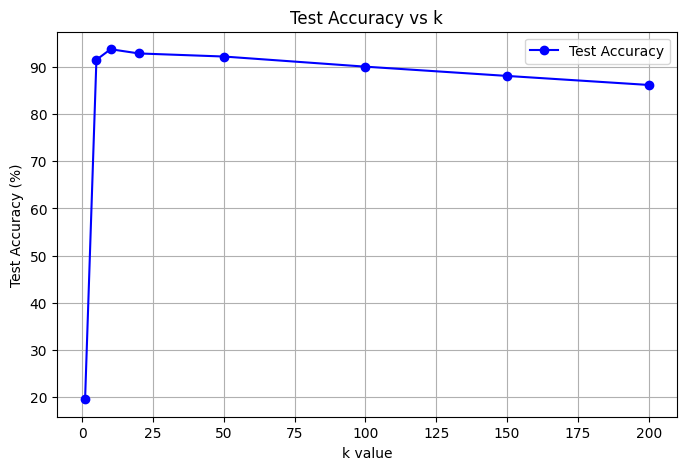

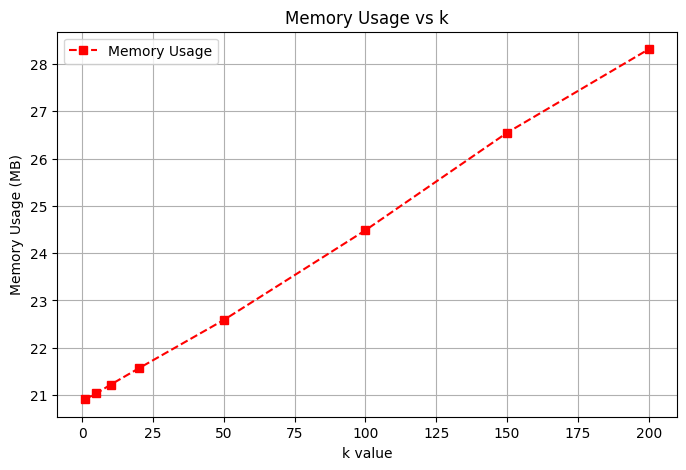

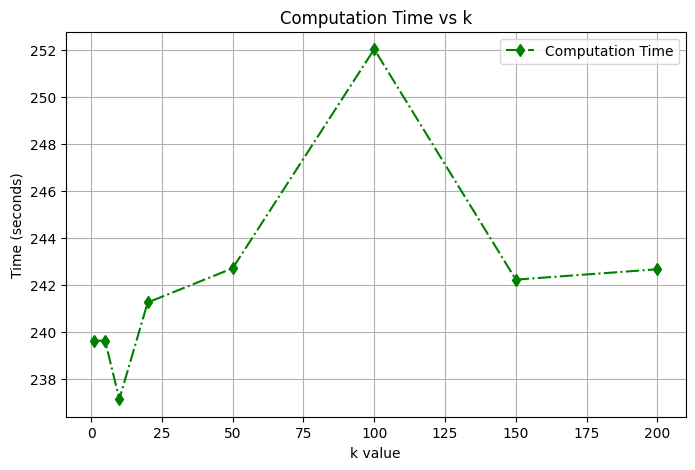

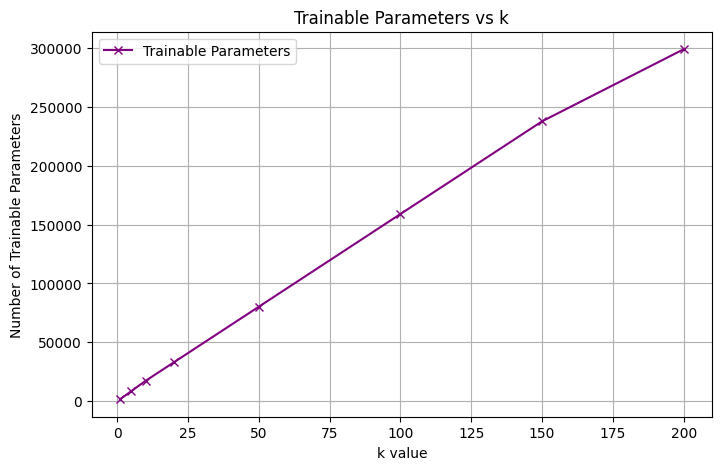

Completed


In [30]:
k_values = [1, 5, 10, 20 , 50, 100, 150 , 200]
test_different_k(k_values, train_loader, test_loader, num_epochs=30)